## **1. Khởi tạo cấu hình và nạp dữ liệu sạch**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style("ticks")

# Đọc dữ liệu đã làm sạch
df = pd.read_csv("SF_Tree_Maintenance_Daily_Data_Cleaned.csv", parse_dates=["date"])

# Kiểm tra tổng quan để đảm bảo dữ liệu chuẩn
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273224 entries, 0 to 273223
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   nbhd            273224 non-null  object        
 1   date            273224 non-null  datetime64[ns]
 2   n               273224 non-null  int64         
 3   permits_active  273224 non-null  int64         
 4   PRCP            273224 non-null  float64       
 5   AWND            273224 non-null  float64       
 6   TMAX            273224 non-null  float64       
 7   year            273224 non-null  int64         
 8   month           273224 non-null  int64         
 9   dow             273224 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 20.8+ MB
None


## **2. Kiểm tra phân phối dữ liệu**

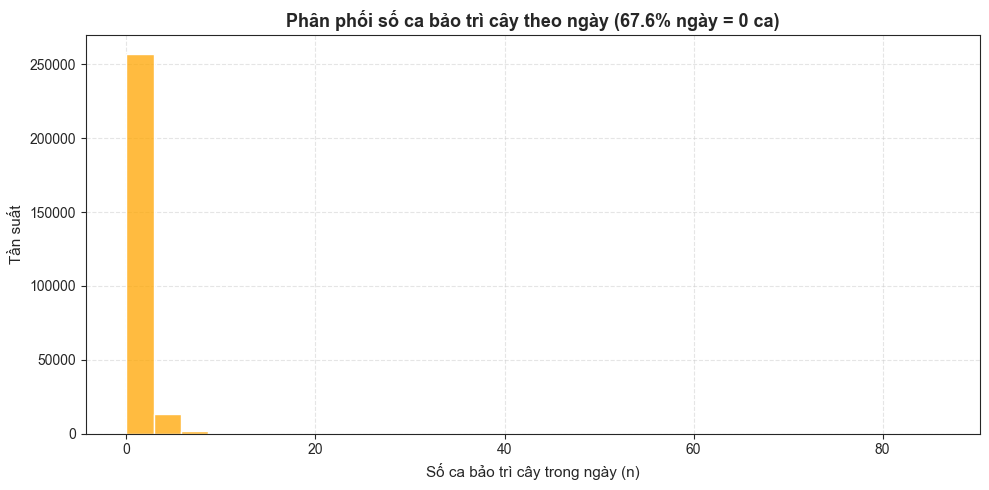

In [2]:
# Phân phối số ca bảo trì cây (n) toàn bộ dữ liệu -- bỏ KDE vì 67.6% dữ liệu = 0 khiến KDE bị lệch biên
plt.figure(figsize=(10, 5))
sns.histplot(df["n"], bins=30, kde=False, color="orange")
plt.xlabel("Số ca bảo trì cây trong ngày (n)", fontsize=11)
plt.ylabel("Tần suất", fontsize=11)
plt.title(f"Phân phối số ca bảo trì cây theo ngày (67.6% ngày = 0 ca)", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("fig_01_distribution_n.png", dpi=300)
plt.show()


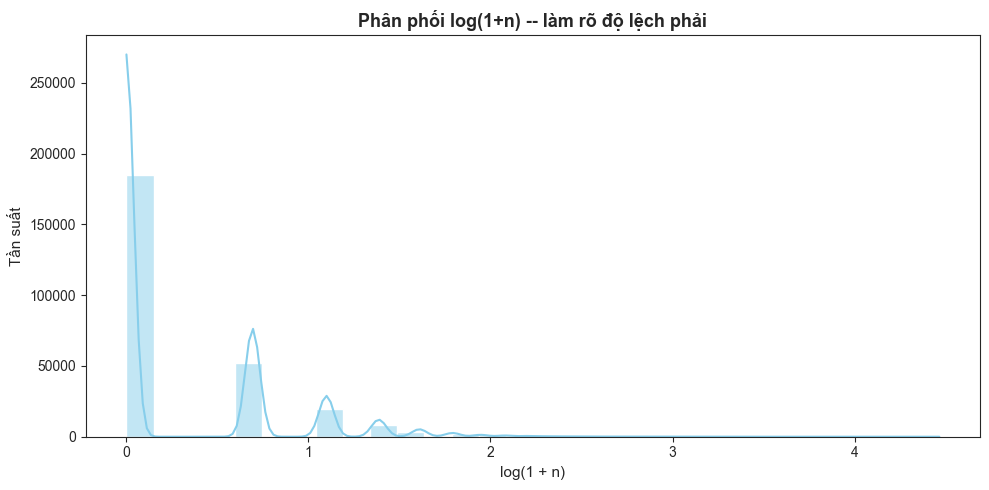

Độ lệch (skewness) của n: 8.502


In [3]:
# Phân phối sau khi biến đổi log(1+n) -- để nhìn rõ hơn phần đuôi dài (right-skewed)
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["n"]), bins=30, kde=True, color="skyblue")
plt.xlabel("log(1 + n)", fontsize=11)
plt.ylabel("Tần suất", fontsize=11)
plt.title("Phân phối log(1+n) -- làm rõ độ lệch phải", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_02_distribution_log_n.png", dpi=300)
plt.show()

print("Độ lệch (skewness) của n:", round(df["n"].skew(), 3))


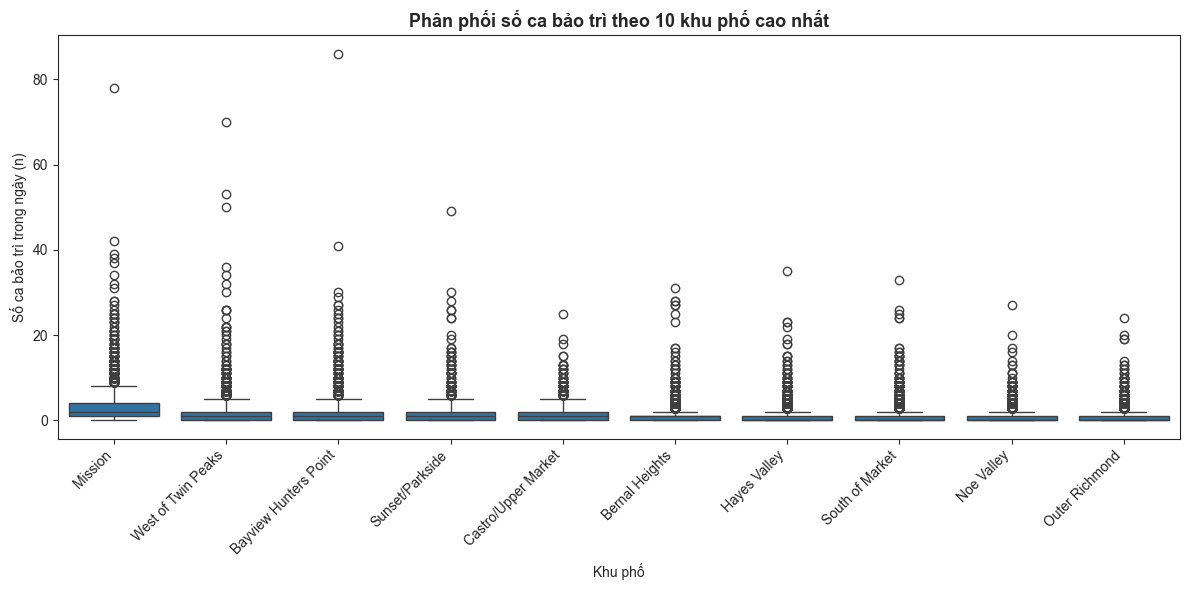

In [4]:
# Boxplot số ca theo 10 khu phố có nhu cầu cao nhất -- xem outlier/đột biến của từng khu phố
top10_nbhd = df.groupby("nbhd")["n"].mean().sort_values(ascending=False).head(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df["nbhd"].isin(top10_nbhd)],
    x="nbhd", y="n", order=top10_nbhd, showfliers=True
)
plt.title("Phân phối số ca bảo trì theo 10 khu phố cao nhất", fontsize=13, fontweight="bold")
plt.xlabel("Khu phố")
plt.ylabel("Số ca bảo trì trong ngày (n)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fig_03_boxplot_top10_nbhd.png", dpi=300)
plt.show()


## **3. Phân tích theo thời gian**

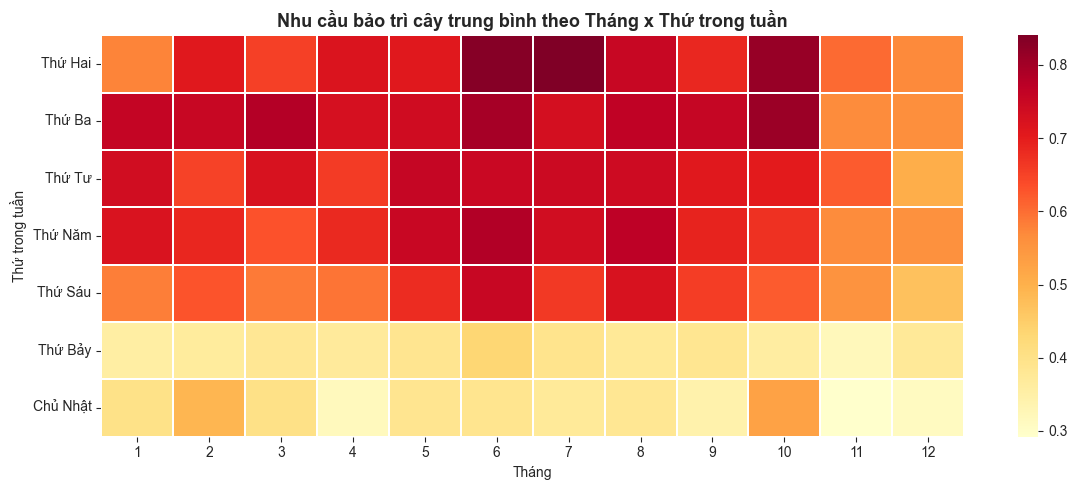

In [5]:
# Heatmap: nhu cầu trung bình theo tháng x thứ trong tuần
heatmap_data = df.pivot_table(index="dow", columns="month", values="n", aggfunc="mean")
dow_labels = ["Thứ Hai", "Thứ Ba", "Thứ Tư", "Thứ Năm", "Thứ Sáu", "Thứ Bảy", "Chủ Nhật"]
heatmap_data.index = dow_labels

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, linecolor="white", annot=False)
plt.xlabel("Tháng")
plt.ylabel("Thứ trong tuần")
plt.title("Nhu cầu bảo trì cây trung bình theo Tháng x Thứ trong tuần", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_04_heatmap_month_dow.png", dpi=300)
plt.show()


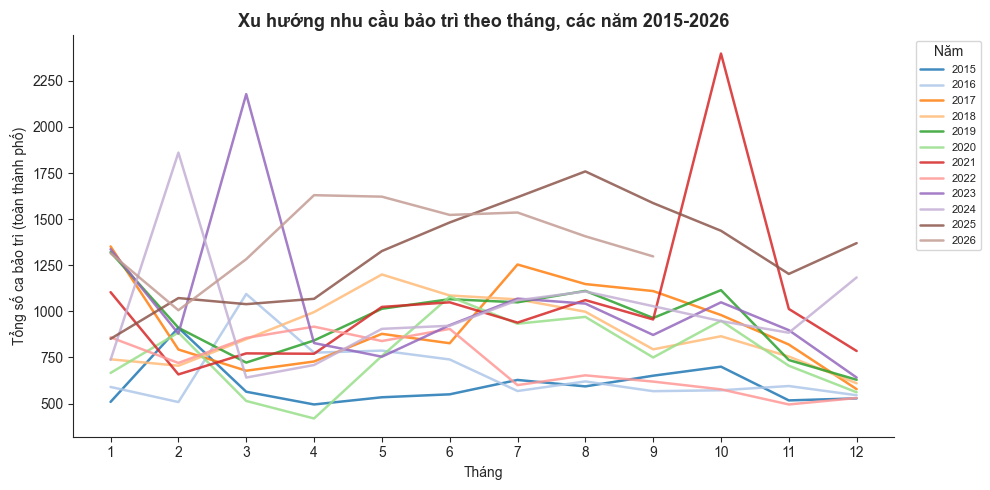

In [6]:
# Xu hướng theo tháng, so sánh giữa các năm (chỉ lấy từ 2015 để đường biểu diễn đỡ rối do dữ liệu đầy đủ hơn)
monthly_trend = (
    df[df["year"] >= 2015]
    .groupby(["year", "month"])["n"].sum()
    .unstack(level=0)
)

palette = sns.color_palette("tab20", n_colors=len(monthly_trend.columns))

plt.figure(figsize=(10, 5))
for color, year in zip(palette, monthly_trend.columns):
    plt.plot(monthly_trend.index, monthly_trend[year], label=str(year), linewidth=1.8, alpha=0.85, color=color)

sns.despine()
plt.xticks(range(1, 13))
plt.xlabel("Tháng")
plt.ylabel("Tổng số ca bảo trì (toàn thành phố)")
plt.title("Xu hướng nhu cầu bảo trì theo tháng, các năm 2015-2026", fontsize=13, fontweight="bold")
plt.legend(title="Năm", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig_05_monthly_trend_by_year.png", dpi=300)
plt.show()


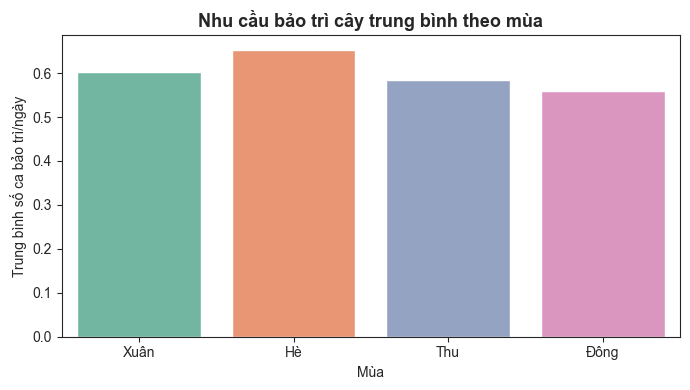

In [7]:
# Nhu cầu trung bình theo mùa (trực quan hoá lại kết quả Query 4 ở Notebook 3)
season_map = {12: "Đông", 1: "Đông", 2: "Đông",
              3: "Xuân", 4: "Xuân", 5: "Xuân",
              6: "Hè", 7: "Hè", 8: "Hè",
              9: "Thu", 10: "Thu", 11: "Thu"}
df["season"] = df["month"].map(season_map)

season_order = ["Xuân", "Hè", "Thu", "Đông"]
season_avg = df.groupby("season")["n"].mean().reindex(season_order)

plt.figure(figsize=(7, 4))
sns.barplot(x=season_avg.index, y=season_avg.values, hue=season_avg.index, palette="Set2", legend=False)
plt.xlabel("Mùa")
plt.ylabel("Trung bình số ca bảo trì/ngày")
plt.title("Nhu cầu bảo trì cây trung bình theo mùa", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_06_avg_by_season.png", dpi=300)
plt.show()


## **4. Phân tích tương quan với các yếu tố ngoại sinh**

In [8]:
# Chỉ phân tích tương quan từ 2015 trở đi, vì permits_active/PRCP/AWND/TMAX
# trước năm này là dữ liệu giả định (đã nêu rõ ở Notebook 2), đưa vào sẽ làm sai lệch hệ số tương quan
df_corr = df[df["date"] >= "2015-01-01"].copy()
print("Số dòng dùng để phân tích tương quan:", df_corr.shape[0])


Số dòng dùng để phân tích tương quan: 175849


In [9]:
# Bảng hệ số tương quan Spearman giữa n và các biến ngoại sinh
exog_cols = ["permits_active", "PRCP", "AWND", "TMAX"]
corr_table = []

for col in exog_cols:
    rho, pval = spearmanr(df_corr["n"], df_corr[col])
    corr_table.append({"bien": col, "spearman_rho": round(rho, 3), "p_value": round(pval, 5)})

corr_table = pd.DataFrame(corr_table).sort_values("spearman_rho", key=abs, ascending=False)
print("Bảng tương quan Spearman giữa n và các biến ngoại sinh (từ 2015):")
corr_table


Bảng tương quan Spearman giữa n và các biến ngoại sinh (từ 2015):


,bien,spearman_rho,p_value
0,permits_active,0.314,0.0
2,AWND,0.071,0.0
3,TMAX,0.038,0.0
1,PRCP,0.013,0.0


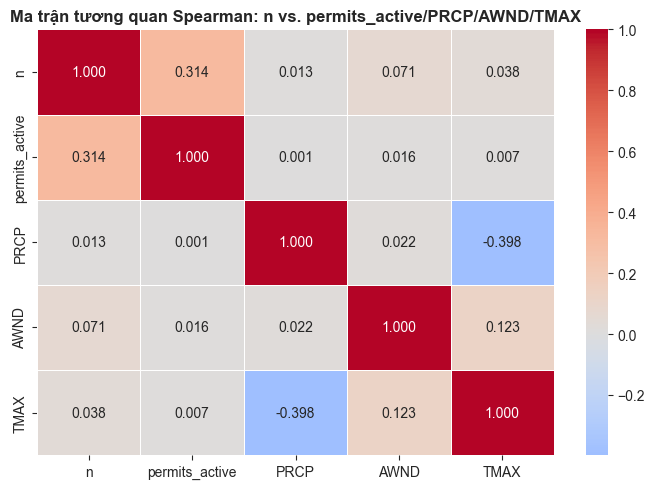

In [10]:
# Heatmap ma trận tương quan Spearman giữa n và 4 biến ngoại sinh
corr_matrix = df_corr[["n"] + exog_cols].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Ma trận tương quan Spearman: n vs. permits_active/PRCP/AWND/TMAX", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_07_corr_heatmap.png", dpi=300)
plt.show()


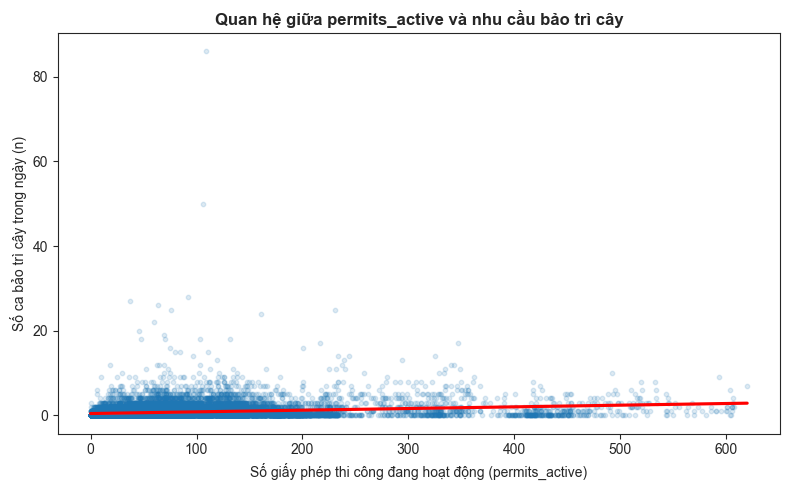

In [11]:
# Scatter + đường hồi quy: n vs permits_active (biến có tương quan mạnh nhất theo bảng trên)
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_corr.sample(min(20000, len(df_corr)), random_state=42),
    x="permits_active", y="n",
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"color": "red"}
)
plt.xlabel("Số giấy phép thi công đang hoạt động (permits_active)")
plt.ylabel("Số ca bảo trì cây trong ngày (n)")
plt.title("Quan hệ giữa permits_active và nhu cầu bảo trì cây", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_08_scatter_permits_vs_n.png", dpi=300)
plt.show()


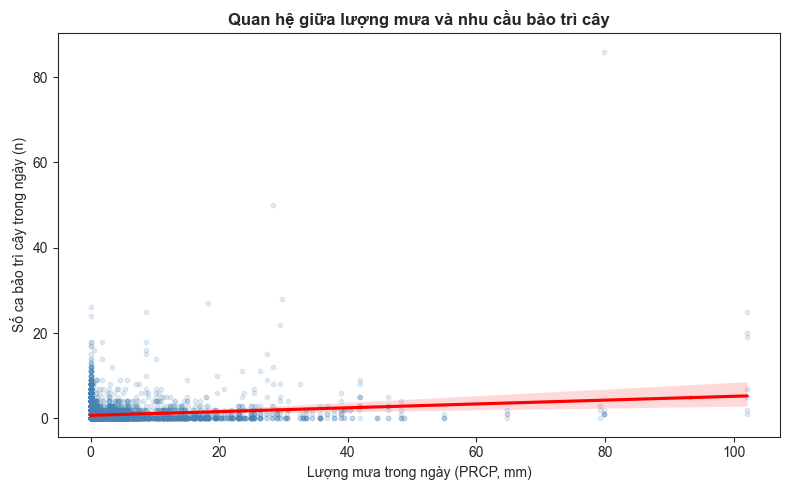

In [12]:
# Scatter + đường hồi quy: n vs PRCP (lượng mưa)
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_corr.sample(min(20000, len(df_corr)), random_state=42),
    x="PRCP", y="n",
    scatter_kws={"alpha": 0.15, "s": 10, "color": "steelblue"},
    line_kws={"color": "red"}
)
plt.xlabel("Lượng mưa trong ngày (PRCP, mm)")
plt.ylabel("Số ca bảo trì cây trong ngày (n)")
plt.title("Quan hệ giữa lượng mưa và nhu cầu bảo trì cây", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_09_scatter_prcp_vs_n.png", dpi=300)
plt.show()


## **5. Phân tích đa biến -- điểm nóng tổng hợp**

In [13]:
# Phân nhóm mức độ hoạt động thi công (permits_active) -- giống ngưỡng đã dùng ở Notebook 3 Query 10
def permit_group(x):
    if x == 0:
        return "1. Không có giấy phép"
    elif x <= 12:
        return "2. Thấp (1-12)"
    elif x <= 65:
        return "3. Trung bình (13-65)"
    else:
        return "4. Cao (>65)"

df_corr["permits_group"] = df_corr["permits_active"].apply(permit_group)

profile = (
    df_corr.groupby(["nbhd", "season", "permits_group"])["n"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "avg_n", "count": "so_dong"})
)
profile["Profile"] = profile["nbhd"] + " | " + profile["season"] + " | " + profile["permits_group"]

top7_profile = profile.sort_values("avg_n", ascending=False).head(7)
top7_profile[["Profile", "avg_n", "so_dong"]]


,Profile,avg_n,so_dong
153,Mission | Hè | 4. Cao (>65),3.836957,1104
154,Mission | Thu | 4. Cao (>65),3.499514,1029
155,Mission | Xuân | 4. Cao (>65),3.409420,1104
158,Mission | Đông | 4. Cao (>65),3.198251,1029
6,Bayview Hunters Point | Đông | 2. Thấp (1-12),2.538462,13
157,Mission | Đông | 3. Trung bình (13-65),2.350000,20
341,West of Twin Peaks | Xuân | 4. Cao (>65),2.223975,634


                                               Profile     avg_n  so_dong
153                        Mission | Hè | 4. Cao (>65)  3.836957     1104
154                       Mission | Thu | 4. Cao (>65)  3.499514     1029
155                      Mission | Xuân | 4. Cao (>65)  3.409420     1104
158                      Mission | Đông | 4. Cao (>65)  3.198251     1029
341           West of Twin Peaks | Xuân | 4. Cao (>65)  2.223975      634
343  West of Twin Peaks | Đông | 3. Trung bình (13-65)  2.220339      472
338   West of Twin Peaks | Thu | 3. Trung bình (13-65)  2.124601      313


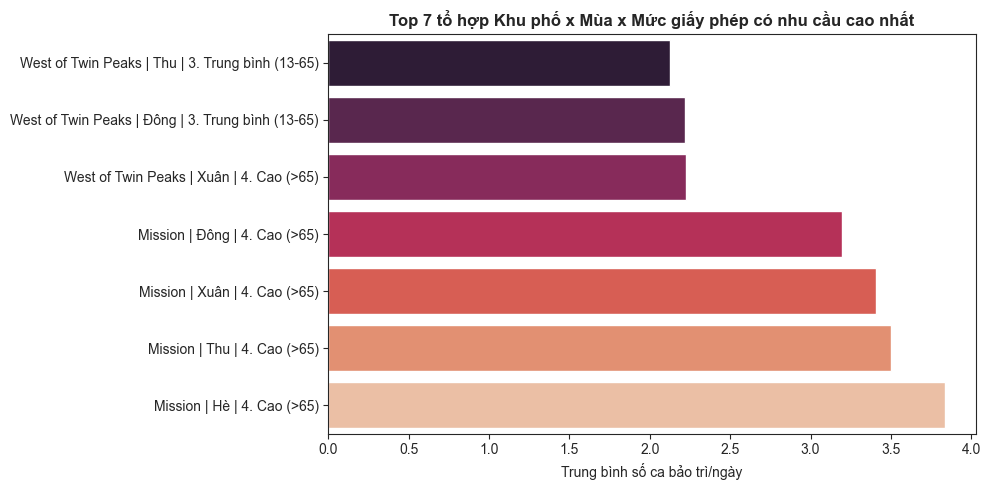

In [18]:
# Trực quan hoá Top 7 tổ hợp (profile) có nhu cầu bảo trì cao nhất 
# Chỉ giữ các tổ hợp có đủ số ngày quan sát (>=100) để đảm bảo avg_n đáng tin cậy, tránh nhiễu từ mẫu nhỏ
top7_profile = (
    profile[profile["so_dong"] >= 100]
    .sort_values("avg_n", ascending=False)
    .head(7)
)
print(top7_profile[["Profile", "avg_n", "so_dong"]])

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top7_profile.sort_values("avg_n"),
    x="avg_n", y="Profile",
    hue="Profile", palette="rocket", legend=False
)
plt.xlabel("Trung bình số ca bảo trì/ngày")
plt.ylabel("")
plt.title("Top 7 tổ hợp Khu phố x Mùa x Mức giấy phép có nhu cầu cao nhất", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_10_top7_profile.png", dpi=300)
plt.show()


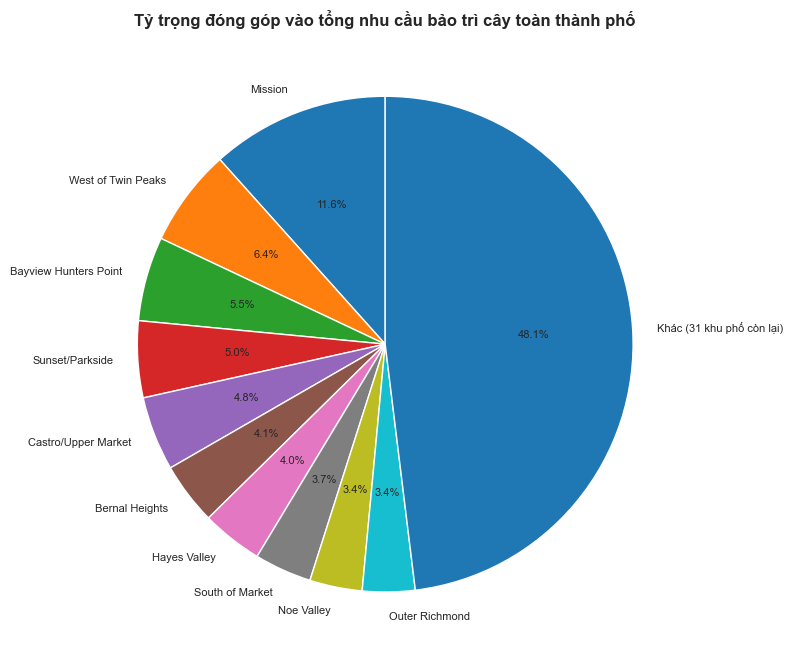

In [15]:
# Tỷ trọng đóng góp của từng khu phố vào tổng nhu cầu toàn thành phố (top 10 + "Khác")
nbhd_total = df.groupby("nbhd")["n"].sum().sort_values(ascending=False)
top10 = nbhd_total.head(10)
other = pd.Series({"Khác (31 khu phố còn lại)": nbhd_total.iloc[10:].sum()})
pie_data = pd.concat([top10, other])

plt.figure(figsize=(8, 8))
plt.pie(
    pie_data.values, labels=pie_data.index, autopct="%1.1f%%",
    startangle=90, textprops={"fontsize": 8}
)
plt.title("Tỷ trọng đóng góp vào tổng nhu cầu bảo trì cây toàn thành phố", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_11_pie_contribution.png", dpi=300)
plt.show()


## **6. Xuất bảng kết quả**

In [16]:
corr_table.to_csv("eda_01_corr_table.csv", index=False)
top7_profile.to_csv("eda_02_top7_profile.csv", index=False)
nbhd_total.reset_index().to_csv("eda_03_nbhd_total.csv", index=False)

print("Đã lưu xong các bảng kết quả EDA.")


Đã lưu xong các bảng kết quả EDA.
